In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


Customer Clusters:

Customer 1: Income=15, Spending=39, Cluster=0
Customer 2: Income=16, Spending=42, Cluster=0
Customer 3: Income=17, Spending=40, Cluster=0
Customer 4: Income=18, Spending=44, Cluster=0
Customer 5: Income=20, Spending=45, Cluster=0
Customer 6: Income=70, Spending=80, Cluster=1
Customer 7: Income=72, Spending=82, Cluster=1
Customer 8: Income=75, Spending=85, Cluster=1
Customer 9: Income=73, Spending=88, Cluster=1
Customer 10: Income=78, Spending=84, Cluster=1
Customer 11: Income=35, Spending=15, Cluster=2
Customer 12: Income=37, Spending=18, Cluster=2
Customer 13: Income=40, Spending=16, Cluster=2
Customer 14: Income=42, Spending=20, Cluster=2
Customer 15: Income=120, Spending=10, Cluster=-1
Customer 16: Income=10, Spending=100, Cluster=-1

Noise / Outliers:
[[120  10]
 [ 10 100]]

Number of clusters: 3


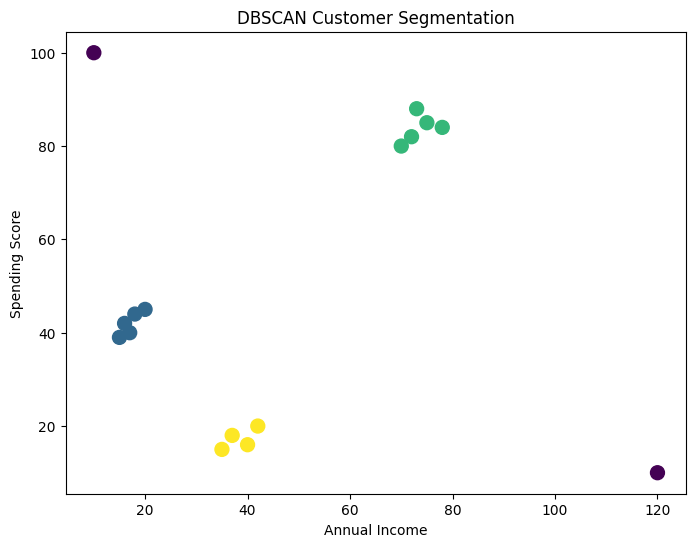

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------
# 1. Customer data
# ------------------------------------------------

X = np.array([
    [15, 39],
    [16, 42],
    [17, 40],
    [18, 44],
    [20, 45],

    [70, 80],
    [72, 82],
    [75, 85],
    [73, 88],
    [78, 84],

    [35, 15],
    [37, 18],
    [40, 16],
    [42, 20],

    # unusual customers
    [120, 10],
    [10, 100]
])


# ------------------------------------------------
# 2. Scale features
# ------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ------------------------------------------------
# 3. Create DBSCAN
# ------------------------------------------------

dbscan = DBSCAN(
    eps=0.5,
    min_samples=3
)


# ------------------------------------------------
# 4. Fit DBSCAN
# ------------------------------------------------

clusters = dbscan.fit_predict(X_scaled)


# ------------------------------------------------
# 5. Print results
# ------------------------------------------------

print("Customer Clusters:\n")

for i, (customer, cluster) in enumerate(
    zip(X, clusters)
):
    print(
        f"Customer {i+1}: "
        f"Income={customer[0]}, "
        f"Spending={customer[1]}, "
        f"Cluster={cluster}"
    )


# ------------------------------------------------
# 6. Find noise
# ------------------------------------------------

noise = X[clusters == -1]

print("\nNoise / Outliers:")
print(noise)


# ------------------------------------------------
# 7. Number of clusters
# ------------------------------------------------

number_of_clusters = len(
    set(clusters)
) - (1 if -1 in clusters else 0)

print(
    "\nNumber of clusters:",
    number_of_clusters
)


# ------------------------------------------------
# 8. Visualization
# ------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters,
    s=100,
    cmap="viridis"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title(
    "DBSCAN Customer Segmentation"
)

plt.show()